## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [2]:
import sys
import os
sys.path.insert(0, 'C:\\Users/jnka0003/Git repos/CIBUSmod')

Import CIBUSmod and packages for handling data and plotting

In [3]:
import CIBUSmod as cm

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Set up scenarios

In [13]:
# Create session
session = cm.Session(
    name = 'FORMAS',
    data_path = 'C:\\Users/jnka0003/Git repos/CIBUSmod/data',
    data_path_scenarios = 'scenarios',
    data_path_output = 'output',
)

# Define scenarios
session.add_scenario(
    name = 'BL',
    scenario_workbooks = None, 
    modules = 'all',
    pars = 'all',
    years = 0
)
session.add_scenario(
    name = 'MAX_CUR',
    scenario_workbooks = 'sng_area', 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'STEERS',
    scenario_workbooks = ['sng_area', 'STEERS'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'CUL_COWS',
    scenario_workbooks = ['sng_area', 'CUL_COWS'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'DRY_COWS',
    scenario_workbooks = ['sng_area', 'DRY_COWS'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'WIN_LAMB',
    scenario_workbooks = ['sng_area', 'WIN_LAMB'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'REC_HORSES',
    scenario_workbooks = ['sng_area', 'REC_HORSES'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'NAT_HORSES',
    scenario_workbooks = ['sng_area', 'NAT_HORSES'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'ALL',
    scenario_workbooks = ['sng_area', 'STEERS', 'CULandDRY_COWS',
                          'WIN_LAMB', 'REC_HORSES'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)
session.add_scenario(
    name = 'ALL + NAT_HORSES',
    scenario_workbooks = ['sng_area', 'STEERS', 'CULandDRY_COWS',
                          'WIN_LAMB', 'REC_HORSES', 'NAT_HORSES'], 
    modules = 'all',
    pars = 'all',
    years = [70, 100, 110]
)

A scenario with the name 'BL' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'MAX_CUR' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'STEERS' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'CUL_COWS' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'DRY_COWS' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'WIN_LAMB' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'REC_HORSES' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'ALL' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'ALL + NAT_HORSES' already exists use .update_scenario() or .remove_scenario() instead.


### Styling

In [11]:
from matplotlib.colors import ListedColormap

# Common style for plots
bar_style = {
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'bar_width' : 0.6
}

bar_style_one = {
    'color' : 'lightgrey',
    'edgecolor' : 'grey'
}

map_style = {
    'cmap' : 'YlOrBr',
    'edgecolor' : 'grey'
}

map_style_r = map_style.copy()
map_style_r['cmap'] = map_style_r['cmap'] + '_r'

map_style_div = {
    'cmap' : 'BrBG',
    'edgecolor' : 'grey'
}

# Get final iteration of each scenario
scn_final = [(scn, '110' if '110' in years else '0') for scn, years in session.scenarios('has output').items()]

rename_years = {
    '0' : '',
    '70' : '-30% CH4',
    '100' : '+/-0% CH4',
    '110' : '+10% CH4'
}

rename_scn = lambda x: x.lower().replace('_','-') if x != 'BL' else 'Baseline'

# Sensitivity analysis Scenarios 
sens = []

# Scenario sort
sort = list(
    session.get_attr('c','area',{'crop':['land_use',None]})
    .loc[:,'semi-natural grasslands']
    .xs('100', level='year')
    .sum(axis=1)
    .sort_values()
    .index
)
# Add BL and remove sensitivity analysis scenarios
sort = ['BL'] + [s for s in sort if s not in sens]

def _legend_r(ax):  
    ax.legend(loc='center left', bbox_to_anchor=(1,0.5), frameon=False, ncol=1, fontsize=9, reverse=True)
def _legend_t(ax):  
    ax.legend(loc='lower center', bbox_to_anchor=(0.5,1.3), frameon=False, ncol=2, fontsize=9, reverse=True)

def _LSU(x):
    '''Gives livestock units (LSU) per head based on a tuple of (species, breed, animal)
    according to https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Glossary:Livestock_unit_(LSU)'''
    sp,br,an = x
    if sp == 'cattle':
        if an == 'cows':
            if br == 'dairy':
                return 1
            else:
                return 0.8
        elif an == 'calves':
            return 0.4
        elif an == 'breeding bulls':
            return 1
        else:
            return 0.8
    elif sp == 'sheep':
        return 0.1
    elif sp == 'pigs':
        if an == 'piglets':
            return 0.027
        elif an == 'sows':
            return 0.5
        else:
            return 0.3
    elif sp == 'horses':
        return 0.8
    elif sp == 'poultry':
        if an == 'broilers':
            return 0.007
        else:
            return 0.014
    else:
        return np.nan

## Plot results

### Bars: Main results

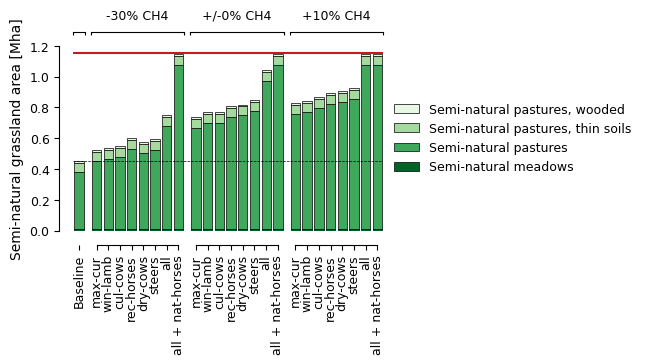

In [12]:
# SNG AREA ---------------------------------------------------------------------- ##
fig, ax = plt.subplots(figsize=(4,2.4))
plot_data = (
    session.get_attr('c','area',{'crop':['land_use',None]})
    .loc[:,'semi-natural grasslands']
    .rename(rename_years)
)/1_000_000

max_sng = session.get_attr('r','max_land_use','land_use').loc[('MAX_CUR','100'),'semi-natural grasslands'] / 1_000_000

cm.plot.bar(
    plot_data.loc[sort].rename(rename_scn, level='scn'),
    ax=ax,
    group_levels='year',
    sort_xlabels=False,
    sort_groups=False,
    cmap='Greens',
    ylabel='Semi-natural grassland area [Mha]',
    ylabel_fontsize=10,
    grouplabels_fontsize=9,
    ticklabels_fontsize=9,
    ylim = (0,1.2)
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
ax.axhline(max_sng, c='#cb181d', linewidth=1.5, linestyle='-')
_legend_r(ax)

plt.show()

species,"cattle, beef","cattle, dairy","horses, cons.","horses, recr.",pigs,poultry,sheep
scn,,,,,,,
MAX_CUR,1,1,0,-0,0,0,0
WIN_LAMB,-5,-8,0,-0,0,0,9
CUL_COWS,-15,11,0,-0,0,0,-1
REC_HORSES,1,1,0,0,0,0,0
DRY_COWS,-21,12,0,-0,0,0,-1
STEERS,-7,-14,0,-0,0,0,-3
ALL,-43,11,0,0,0,0,4
ALL + NAT_HORSES,-57,-16,161,-0,0,0,2


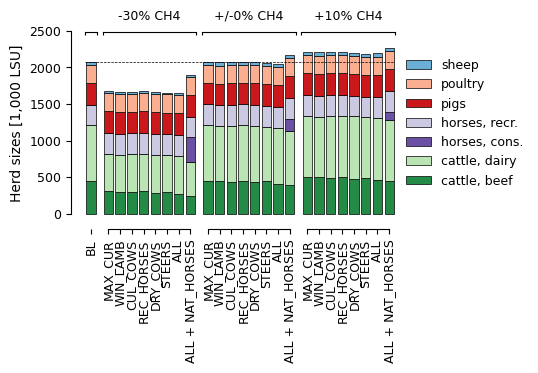

In [9]:
plot_data = (
    session.get_attr('a','heads',['species','breed','animal'])
    .rename(rename_years)
) / 1_000
# Convert to LSU
plot_data = plot_data.mul([_LSU(x) for x in plot_data.columns], axis=1)

plot_data.columns = pd.Index(
    [f'{sp}, {br}' if sp == 'cattle'
     else 'horses, recr.' if sp == 'horses' and 'cons' not in br
     else 'horses, cons.' if sp == 'horses'
     else sp
     for sp,br,an in plot_data.columns],
    name = 'species'
)

plot_data = plot_data.T.groupby('species').sum().T

display(plot_data.loc[sort].sub(plot_data.loc[('BL','')], axis=1).xs('+/-0% CH4', level='year').style.format('{:,.0f}'))

fig, ax = plt.subplots(figsize=(4,2.4))
cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    group_levels='year',
    sort_xlabels=False,
    sort_groups=False,
    cmap=ListedColormap(name='X', colors=['#238b45','#bae4b3', '#6a51a3', '#cbc9e2', '#cb181d', '#fcae91', '#6baed6']),
    ylabel='Herd sizes [1,000 LSU]',
    ylabel_fontsize=10,
    grouplabels_fontsize=9,
    ticklabels_fontsize=9
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_r(ax)

plt.show()

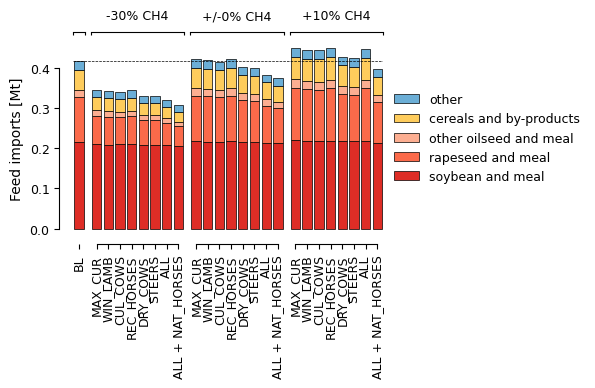

In [10]:
by_prod_agg = {
    'fish meal' : 'other',
    'luzern meal' : 'other',
    'milling by-products from wheat, barley or rye' : 'cereals and by-products',
    'palm kernel expeller' : 'other oilseed and meal',
    'potatoe protein' : 'other',
    'rapeseed cake' : 'rapeseed and meal',
    'rapeseed meal' : 'rapeseed and meal',
    'soybean meal' : 'soybean and meal',
    'soybean protein concentrate' : 'soybean and meal',
    'sugar beet molasses' : 'other',
    'sugar beet pulp' : 'other',
    'sunflower seed meal' : 'other oilseed and meal',
    'wheat distillers grain' : 'cereals and by-products'
}

crop_prod_agg = {
    'linseed' : 'other oilseed and meal',
    'maize' : 'cereals and by-products',
    'soybeans' : 'soybean and meal'
}

plot_data = pd.concat([
    (
        session.get_attr('a','feed.crop_prod',['origin','crop_prod'])
        .loc[:,'imported']
        .rename(columns = crop_prod_agg)
        .rename_axis(columns = 'item')
        .rename(rename_years)
    ),
    (
        session.get_attr('d','by_products',['origin','by_prod'])
        .loc[:,'imported']
        .rename(columns = by_prod_agg)
        .rename_axis(columns = 'item')
        .rename(rename_years)
    )
], axis=1).T.groupby('item').sum().T / 1_000_000_000

item_sort = ['soybean and meal', 'rapeseed and meal', 'other oilseed and meal', 'cereals and by-products', 'other']

fig, ax = plt.subplots(figsize=(4,2.4))
cm.plot.bar(
    plot_data.loc[sort,item_sort],
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#de2d26','#fb6a4a', '#fcae91', '#fecc5c', '#6baed6']),
    ylabel='Feed imports [Mt]',
    ylabel_fontsize=10,
    grouplabels_fontsize=9,
    ticklabels_fontsize=9
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_r(ax)

plt.show()

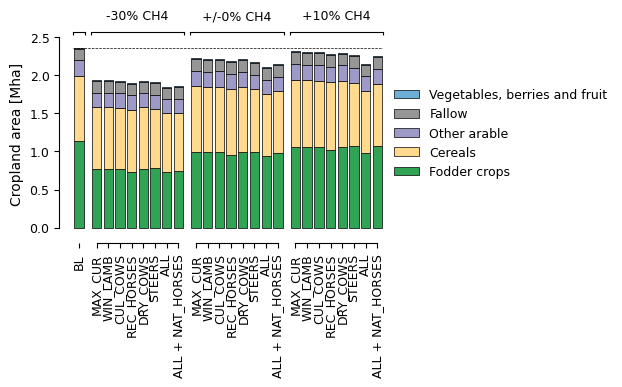

In [11]:
# CROP AREA ---------------------------------------------------------------------- ##

fig, ax = plt.subplots(figsize=(4,2.5))
plot_data = (
    session.get_attr('c','area',{'crop':['land_use','crop_group2']})
    .loc[:,'cropland']
    .rename(rename_years)
)/1000000
cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#31a354','#fed98e', '#9e9ac8', '#969696', '#6baed6']),
    ylabel='Cropland area [Mha]',
    ylabel_fontsize=10,
    grouplabels_fontsize=9,
    ticklabels_fontsize=9
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_r(ax)

plt.show()

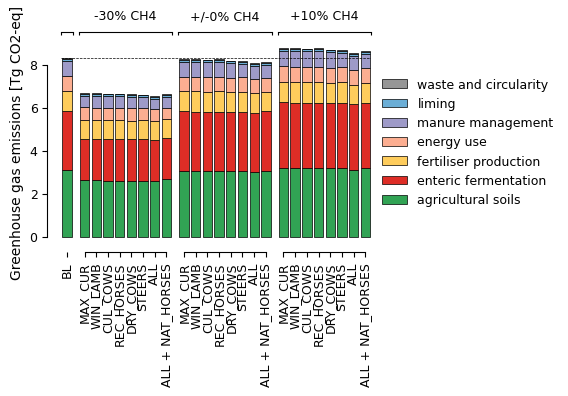

In [12]:
# GHG ---------------------------------------------------------------------- ##

fig, ax = plt.subplots(figsize=(4,2.5))
plot_data = (
    cm.get_GHG(session, CO2eq = True)
    .T.groupby('process').sum().T
    .rename(rename_years)
)/1000000000
cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#31a354','#de2d26', '#fecc5c', '#fcae91', '#9e9ac8', '#6baed6', '#969696']),
    ylabel='Greenhouse gas emissions [Tg CO2-eq]',
    ylabel_fontsize=10,
    grouplabels_fontsize=9,
    ticklabels_fontsize=9
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_r(ax)

plt.show()

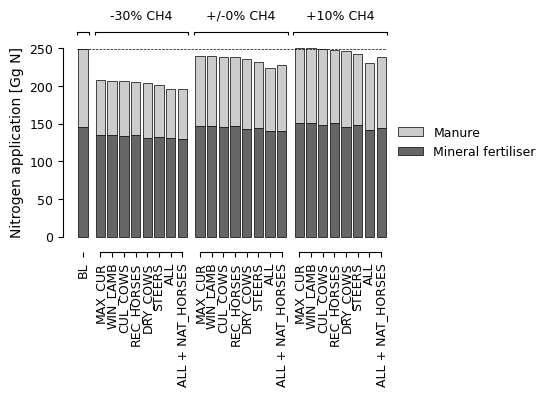

In [13]:
# N FERTILISER ---------------------------------------------------------------------- ##

fig, ax = plt.subplots(figsize=(4,2.5))
plot_data = (
    pd.concat([
        session.get_attr('c','fertiliser.mineral_N', {'crop':'land_use'}).loc[:,'cropland'].rename('Mineral fertiliser'),
        session.get_attr('c','fertiliser.manure_N', {'crop':'land_use'}).loc[:,'cropland'].rename('Manure')
    ], axis=1)
    .rename(rename_years)
)/1000000

cm.plot.bar(
    plot_data.loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#666666','#cccccc']),
    ylabel='Nitrogen application [Gg N]',
    ylabel_fontsize=10,
    grouplabels_fontsize=9,
    ticklabels_fontsize=9
)
ax.axhline(plot_data.loc[('BL','')].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_r(ax)

plt.show()

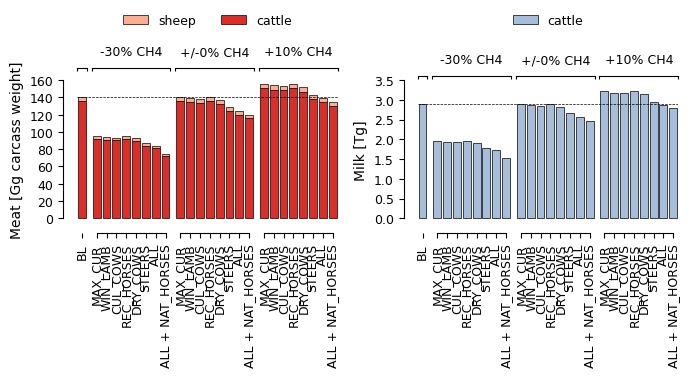

In [27]:
# MEAT AND MILK ---------------------------------------------------------------------- ##
fig, axs = plt.subplots(1,2, figsize=(7,4.5))
plot_data = (
    session.get_attr('a','prod', ['animal_prod','species'])
    .loc[:,(slice(None),['cattle','sheep'])]
    .rename(rename_years)
)/1000000
ax = axs[0]
cm.plot.bar(
    plot_data.loc[:,'meat'].loc[sort],
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#de2d26','#fcae91']),
    ylabel='Meat [Gg carcass weight]',
    ylabel_fontsize=10,
    grouplabels_fontsize=9,
    ticklabels_fontsize=9
)
ax.axhline(plot_data.loc[('BL',''),'meat'].sum(), c='black', linewidth=0.5, linestyle='--')
_legend_t(ax)
ax = axs[1]
cm.plot.bar(
    plot_data.loc[:,'milk'].loc[sort]/1000,
    ax=ax,
    sort_categories=True,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#a6bddb']),
    ylabel='Milk [Tg]',
    ylabel_fontsize=10,
    grouplabels_fontsize=9,
    ticklabels_fontsize=9
)
ax.axhline(plot_data.loc[('BL',''),'milk'].sum()/1000, c='black', linewidth=0.5, linestyle='--')
_legend_t(ax)

plt.tight_layout()
plt.show()

### Bars: Grazing

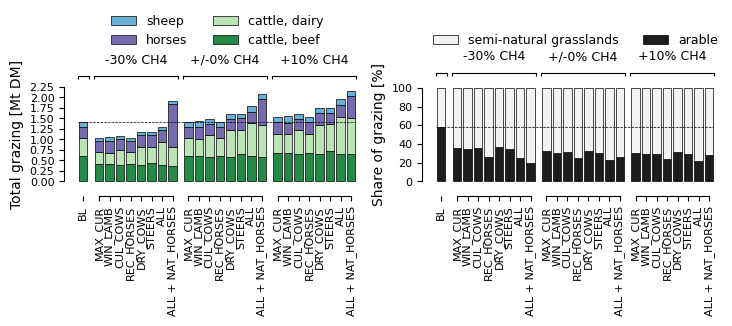

In [15]:
d1 = (
    session
    .get_attr('a','feed.crop_product_demand',['crop_prod','species','breed'])
    .loc[:,'grazing']
    .rename(rename_years)
    .loc[sort]
    /1_000_000_000
)
d1.columns = pd.Index([c[0] if c[0] != 'cattle' else ', '.join(c) for c in d1.columns], name='animal_system')
d1 = d1.T.groupby('animal_system').sum().T

d2 = (
    session
    .get_attr('c','production',{'crop_prod':None, 'crop':'land_use'})
    .loc[:,'grazing']
    .apply(lambda x: x/x.sum()*100, axis=1)
    .rename(rename_years)
    .rename(columns={'cropland':'arable'})
    .loc[sort]
)

fig,axs = plt.subplots(1,2, figsize=(7.5,4))
ax = axs[0]
cm.plot.bar(
    d1,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#238b45','#bae4b3', '#756bb1', '#6baed6']),
    ylabel='Total grazing [Mt DM]',
    ylabel_fontsize=10,
    ticklabels_fontsize=8,
    grouplabels_fontsize=9,
    ax=ax
)
ax.axhline(y=d1.sum(axis=1).loc['BL'].iloc[0], c='black', linewidth=0.5, linestyle='--')

ax = axs[1]
cm.plot.bar(
    d2,
    group_levels='year',
    cmap='Greys',
    ylabel='Share of grazing [%]',
    ylabel_fontsize=10,
    ticklabels_fontsize=8,
    grouplabels_fontsize=9,
    ax=ax
)
ax.axhline(y=d2.loc['BL','arable'].iloc[0], c='black', linewidth=0.5, linestyle='--')

for ax in axs.flatten():
    _legend_t(ax)

plt.tight_layout()
plt.show()

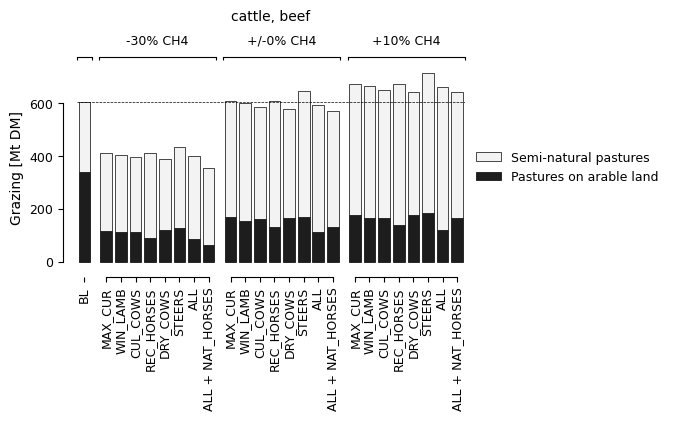

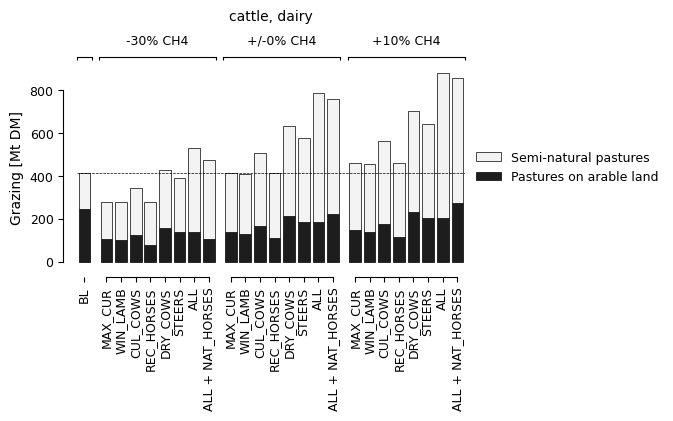

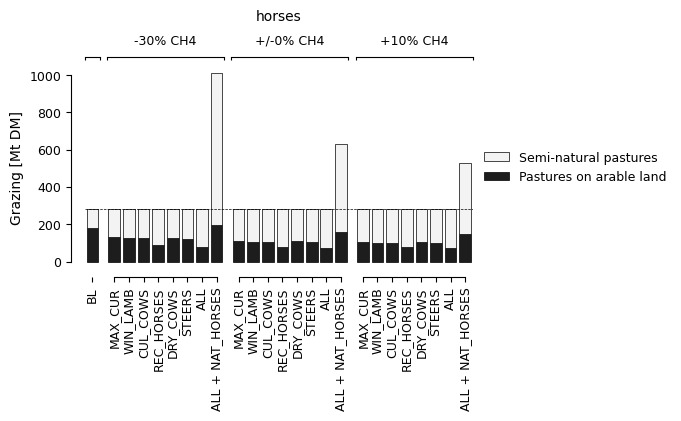

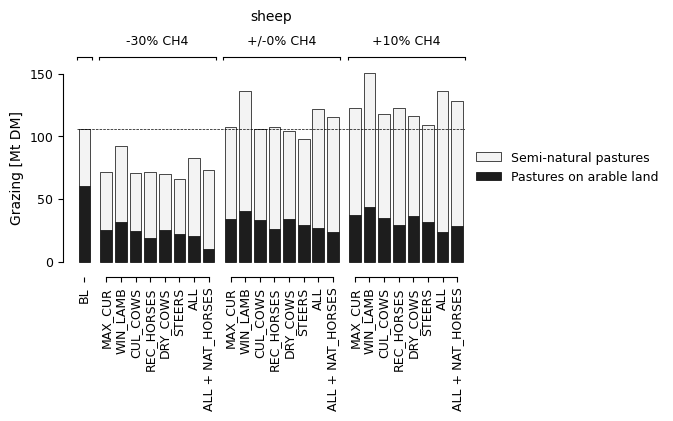

In [16]:
rename_crp = {
    'Ley for grazing' : 'Pastures on arable land',
    'Semi-natural pastures' : 'Semi-natural pastures',
    'Semi-natural pastures, thin soils' : 'Semi-natural pastures',
    'Semi-natural pastures, wooded' : 'Semi-natural pastures'
}

plot_data = (
    session.get_attr('c','production_per_use', ['crop', 'demand'])
    .rename(rename_years)
    .loc[sort,list(rename_crp)]
    .rename(columns=rename_crp, level='crop')
    .rename(
        columns=lambda x:
            'cattle, dairy' if 'cattle, dairy' in x else
            'cattle, beef' if 'cattle, beef' in x else
            'sheep' if 'sheep' in x else
            'horses' if 'horses' in x else
            '',
        level='demand'
    )
    .T.groupby(['crop','demand']).sum().T
    .rename_axis(columns={'demand':'animal_system'})
    .stack('animal_system')
)/1_000_000

for ani in plot_data.index.unique('animal_system'):
    fig,ax = plt.subplots(figsize=(5,2.5))
    d = plot_data.xs(ani, level='animal_system').replace({0:np.nan}).dropna(axis=1)
    cm.plot.bar(
        d,
        ax=ax,
        group_levels=['year'],
        sort_groups=False,
        sort_xlabels=False,
        sort_categories=False,
        grouptitle=ani,
        ylabel='Grazing [Mt DM]',
        ticklabels_fontsize=9,
        grouptitle_fontsize=10,
        grouplabels_fontsize=9,
        ylabel_fontsize=10,
        cmap='Greys'
    )
    ax.axhline(d.loc['BL'].sum(axis=1).iloc[0], c='black', linewidth=0.5, linestyle='--')
    ax.legend(loc='center left', bbox_to_anchor=(1,0.5), frameon=False, ncol=1, fontsize=9, reverse=True)
    plt.show()

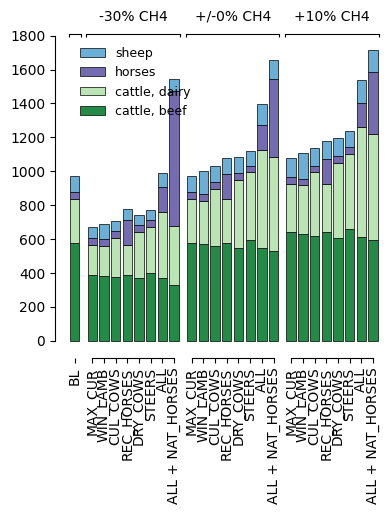

In [17]:
plot_data = (
    session
    .get_attr('a','feed.max_supply_from_crop_group',['crop_group','species','breed'])
    .rename(rename_years)
    .loc[sort,'Semi-natural pastures']
)/1_000_000
plot_data.columns = pd.Index([c[0] if c[0] != 'cattle' else ', '.join(c) for c in plot_data.columns], name='animal_system')
plot_data = plot_data.T.groupby('animal_system').sum().T

fig, ax = plt.subplots(figsize=(4,4))
cm.plot.bar(
    plot_data,
    group_levels='year',
    cmap=ListedColormap(name='X', colors=['#238b45','#bae4b3', '#756bb1', '#6baed6']),
    ax=ax
)
plt.show()

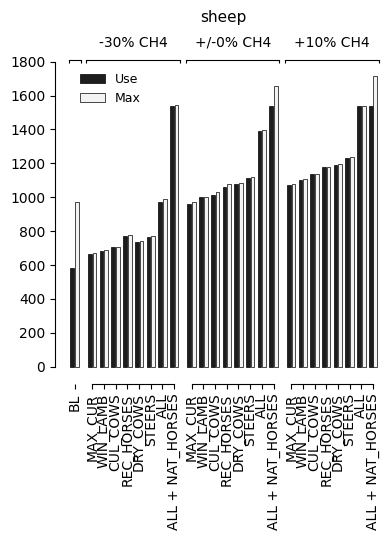

In [18]:
use_df = (
    session.get_attr('c','production', {'crop':'crop_group'})
    .rename(rename_years)
    .loc[sort,'Semi-natural pastures']
    .rename('Use')
)/1_000_000

max_df = (
    session
    .get_attr('a','feed.max_supply_from_crop_group',['crop_group'])
    .rename(rename_years)
    .loc[sort,'Semi-natural pastures']
    .rename('Max')
)/1_000_000

plot_data = pd.concat([use_df,max_df], axis=1)

fig, ax = plt.subplots(figsize=(4,4))
cm.plot.bar(
    plot_data,
    stacked=False,
    group_levels='year',
    cmap='Greys',
    grouptitle=ani,
    ax=ax
)
plt.show()

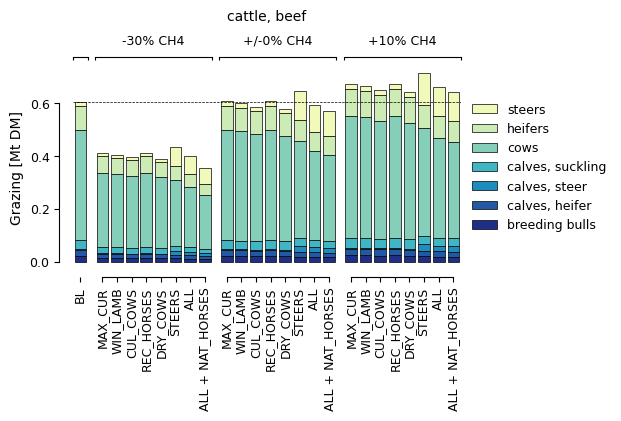

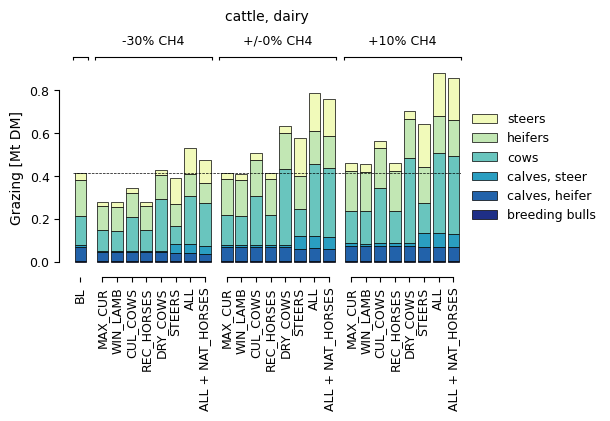

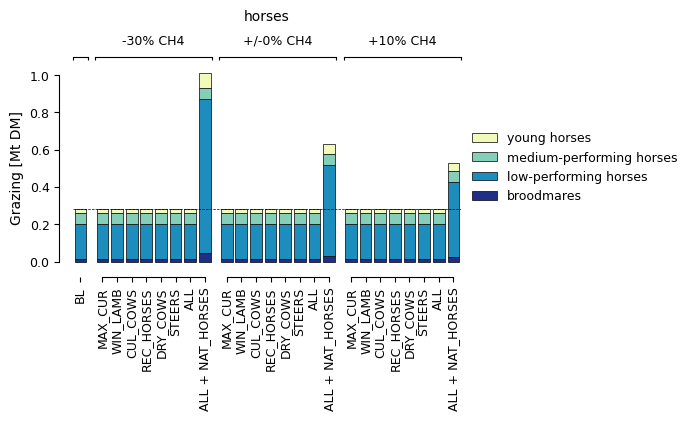

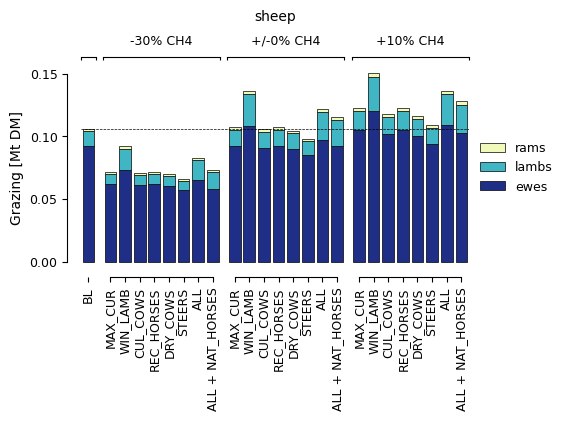

In [19]:
plot_data = (
    session.get_attr('a','feed.crop_prod',['origin','crop_prod','species','breed','animal'])
    .rename(rename_years)
    .loc[sort,('domestic','grazing')]
    .stack(['species','breed'])
)/1_000_000_000
plot_data.index = pd.MultiIndex.from_tuples(
    [( scn, y, sp if sp != 'cattle' else ', '.join([sp,br]) ) for scn,y,sp,br in plot_data.index],
    names = ['scn', 'year', 'animal_system']
)
plot_data = plot_data.groupby(['scn', 'year', 'animal_system'], sort=False).sum()

for ani in plot_data.index.unique('animal_system'):
    fig,ax = plt.subplots(figsize=(5,2.5))
    d = plot_data.xs(ani, level='animal_system').replace({0:np.nan}).dropna(axis=1)
    cm.plot.bar(
        d,
        ax=ax,
        group_levels=['year'],
        sort_groups=False,
        sort_xlabels=False,
        sort_categories=False,
        grouptitle=ani,
        ylabel='Grazing [Mt DM]',
        ticklabels_fontsize=9,
        grouptitle_fontsize=10,
        grouplabels_fontsize=9,
        ylabel_fontsize=10,
        cmap='YlGnBu'
    )
    ax.axhline(d.loc['BL'].sum(axis=1).iloc[0], c='black', linewidth=0.5, linestyle='--')
    ax.legend(loc='center left', bbox_to_anchor=(1,0.5), frameon=False, ncol=1, fontsize=9, reverse=True)
    plt.show()

### Maps: Potential pastures and yield

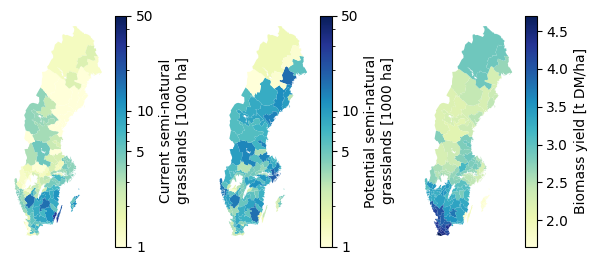

In [20]:
import matplotlib

a0 = session.get_attr('r','x0_crops',{'crop':'land_use', 'region':None}).loc[('BL','0'), 'semi-natural grasslands']/1000
a1 = session.get_attr('r','x0_crops',{'crop':'land_use', 'region':None}).loc[('MAX_CUR','100'), 'semi-natural grasslands']/1000
y = (
    (session.get_attr('c','harvest',{'crop':'land_use','region':None})
    /session.get_attr('c','area',{'crop':'land_use','region':None}))
    .loc[('BL','0'),'semi-natural grasslands']
)/1000

fig, axs = plt.subplots(1,3, figsize=(7.5,3))
ax = axs[0]
cm.plot.map_from_series(a0, cmap='YlGnBu', norm=matplotlib.colors.LogNorm(vmin=1, vmax=50), legend=False, ax=ax)
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Current semi-natural\ngrasslands [1000 ha]', fontsize=10)
cbar.set_ticks([1,5,10,50])
cbar.set_ticklabels(['1','5','10','50'])
ax.axis('off')

ax = axs[1]
cm.plot.map_from_series(a1-a0, cmap='YlGnBu', norm=matplotlib.colors.LogNorm(vmin=1, vmax=50), legend=False, ax=ax)
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Potential semi-natural\ngrasslands [1000 ha]', fontsize=10)
cbar.set_ticks([1,5,10,50])
cbar.set_ticklabels(['1','5','10','50'])
ax.axis('off')

ax=axs[2]
cm.plot.map_from_series(y, cmap='YlGnBu', ax=ax, legend=False)
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Biomass yield [t DM/ha]', fontsize=10)
ax.axis('off')

plt.tight_layout
plt.show()

### Maps: Changes in semi-natural grassland and cropland area

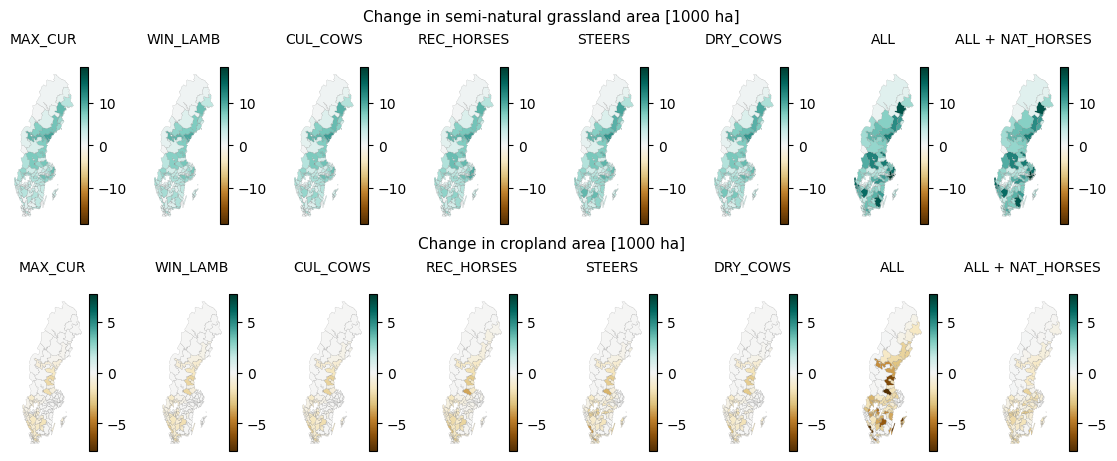

In [21]:
plot_data = (
    session.get_attr('c','area',{'crop':'land_use', 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('BL','0')],axis=1))
    .drop(('BL','0'))
    .droplevel('year')
)/1000

scn_sorted = plot_data.sum(axis=1).sort_values().index

n_scn = len(plot_data)
lims = plot_data.T.abs().groupby('land_use').max().max(axis=1)

fig = plt.figure(layout='constrained', figsize=(1.4*n_scn, 4.5))
subfigs = fig.subfigures(2, 1, wspace=0.07)

# Semi-natural grasslands
axs1 = subfigs[0].subplots(1,n_scn)
for n, scn in enumerate(plot_data.sum(axis=1).sort_values().index):
    ax = axs1[n]
    cm.plot.map_from_series(
        plot_data.loc[scn,'semi-natural grasslands'],
        ax = ax,
        vmin=-lims.loc['semi-natural grasslands'],
        # cmap_zero_midpoint='shrink',
        vmax=lims.loc['semi-natural grasslands'],
        **map_style_div
    )
    ax.set_title(scn, size=10)
    ax.axis('off')
subfigs[0].suptitle('Change in semi-natural grassland area [1000 ha]', size=11)

# Cropland
axs2 = subfigs[1].subplots(1,n_scn)
# fig, axs = plt.subplots(1,n_scn, figsize=(2.2*n_scn,4))
for n, scn in enumerate(plot_data.sum(axis=1).sort_values().index):
    ax = axs2[n]
    cm.plot.map_from_series(
        plot_data.loc[scn,'cropland'],
        ax = ax,
        vmin=-lims.loc['cropland'],
        # cmap_zero_midpoint='shrink',
        vmax=lims.loc['cropland'],
        **map_style_div
    )
    ax.set_title(scn, size=10)
    ax.axis('off')
subfigs[1].suptitle('Change in cropland area [1000 ha]', size=11)

# fig.tight_layout()
plt.show()

(<Axes: >,
 [<Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>,
  <Axes: label='inset_axes'>])

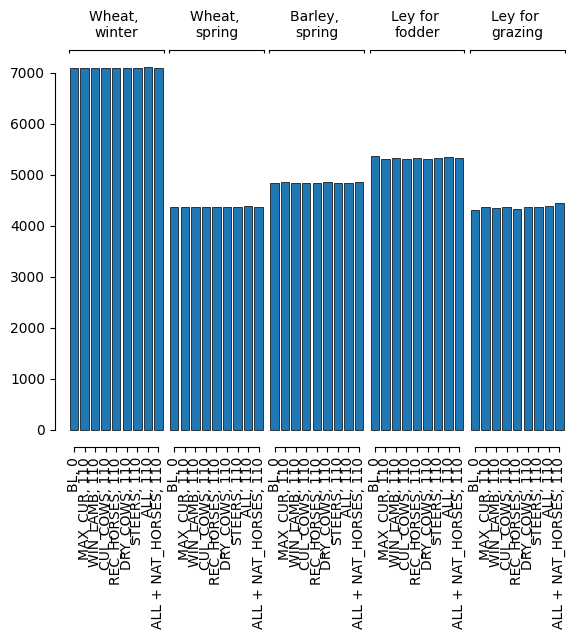

In [22]:
d=(
    (
    session.get_attr('c','harvest',{'crop':None}) /
    session.get_attr('c','area',{'crop':None})
    )
    .loc[scn_final,['Wheat, winter','Wheat, spring', 'Barley, spring', 'Ley for fodder', 'Ley for grazing']]
    .loc[sort]
    .stack()
)

cm.plot.bar(d, group_levels='crop')

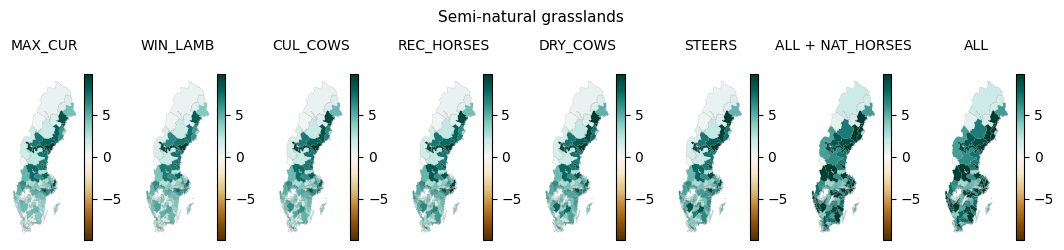

,0,1
scn,,
MAX_CUR,373.8,489.3
WIN_LAMB,387.6,518.5
CUL_COWS,413.1,551.6
REC_HORSES,438.8,591.5
DRY_COWS,450.5,607.9
STEERS,475.2,647.6
ALL + NAT_HORSES,692.9,956.5
ALL,692.9,956.5


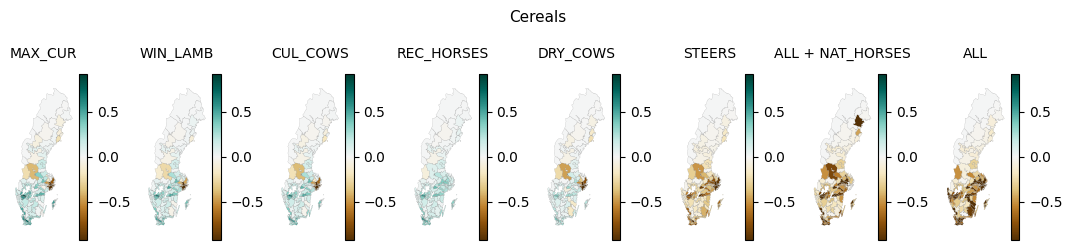

,0,1
scn,,
MAX_CUR,15.1,84.6
WIN_LAMB,13.5,73.9
CUL_COWS,12.2,69.1
REC_HORSES,17.0,88.4
DRY_COWS,4.5,32.0
STEERS,-35.9,-185.2
ALL + NAT_HORSES,-47.2,-243.8
ALL,-58.1,-294.4


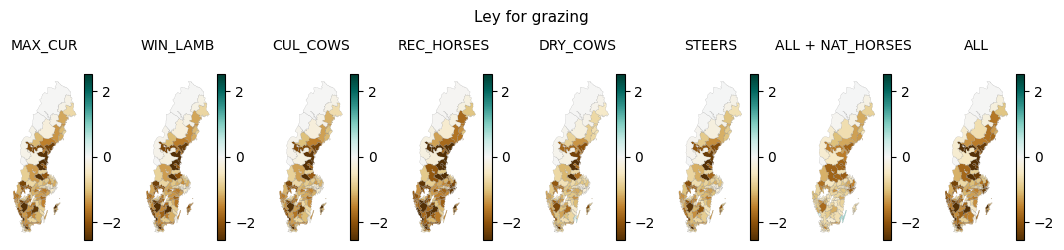

,0,1
scn,,
MAX_CUR,-135.8,-360.4
WIN_LAMB,-140.8,-375.1
CUL_COWS,-130.7,-346.6
REC_HORSES,-172.4,-463.0
DRY_COWS,-105.2,-275.5
STEERS,-117.3,-308.1
ALL + NAT_HORSES,-86.1,-212.6
ALL,-152.0,-402.4


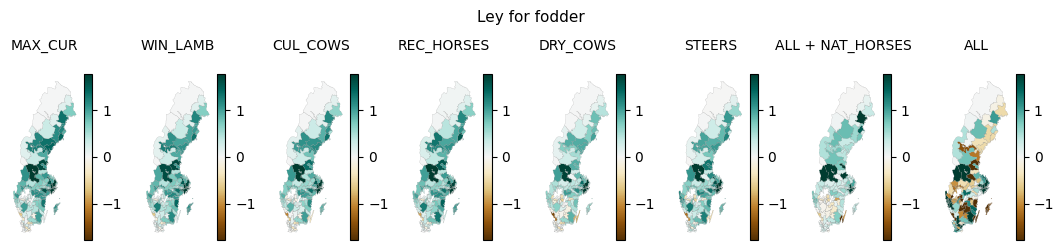

,0,1
scn,,
MAX_CUR,62.0,287.0
WIN_LAMB,63.1,302.4
CUL_COWS,50.8,230.2
REC_HORSES,62.4,297.9
DRY_COWS,34.1,143.9
STEERS,55.4,264.2
ALL + NAT_HORSES,30.0,131.8
ALL,-0.5,-14.3


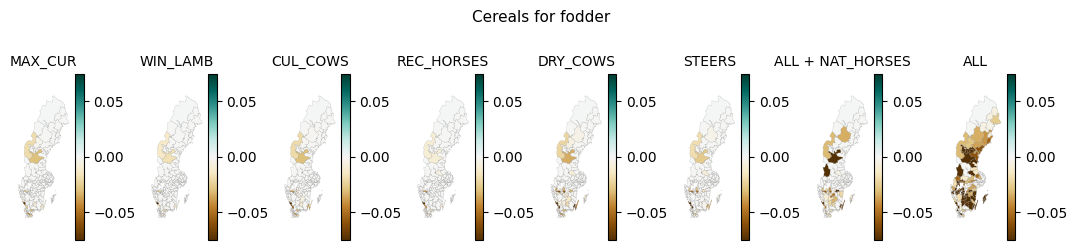

,0,1
scn,,
MAX_CUR,-0.4,-1.5
WIN_LAMB,-0.2,-0.8
CUL_COWS,-0.5,-2.1
REC_HORSES,-0.3,-1.1
DRY_COWS,-1.0,-3.7
STEERS,-0.6,-2.4
ALL + NAT_HORSES,-1.3,-4.5
ALL,-6.6,-22.6


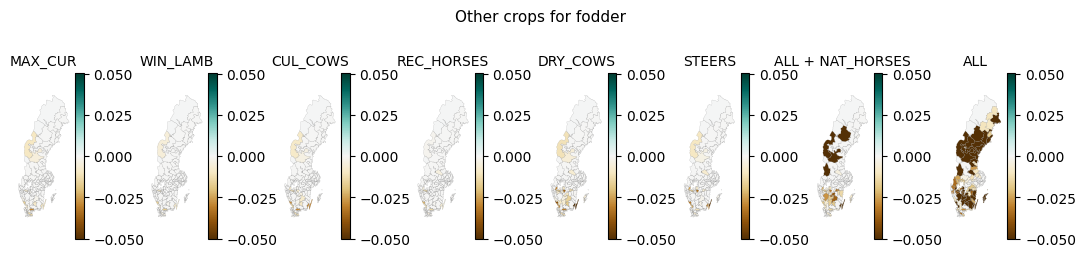

,0,1
scn,,
MAX_CUR,-0.2,-0.8
WIN_LAMB,-0.1,-0.4
CUL_COWS,-0.2,-1.2
REC_HORSES,-0.1,-0.5
DRY_COWS,-0.5,-2.4
STEERS,-0.3,-1.3
ALL + NAT_HORSES,-1.0,-4.0
ALL,-5.2,-22.3


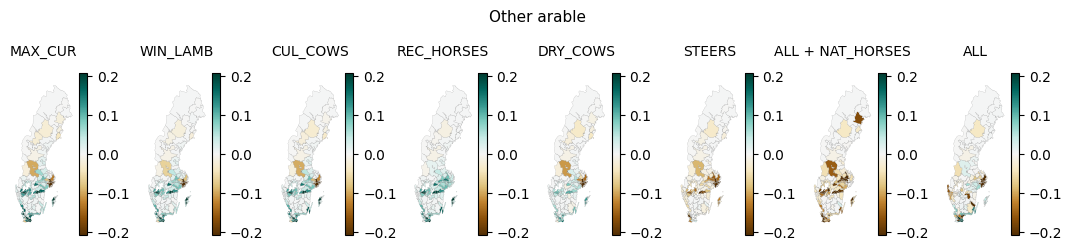

,0,1
scn,,
MAX_CUR,5.0,17.4
WIN_LAMB,4.1,13.9
CUL_COWS,4.0,13.8
REC_HORSES,5.2,16.6
DRY_COWS,1.5,6.3
STEERS,-3.9,-12.4
ALL + NAT_HORSES,-8.2,-26.5
ALL,-1.3,-1.1


In [23]:
d1 = (
    session.get_attr('c','area',{'crop':'crop_group2', 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('BL','0')],axis=1))
    .drop(('BL','0'))
    .droplevel('year')
)/1_000

d2 = (
    session.get_attr('c','area',{'crop':None, 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('BL','0')],axis=1))
    .drop(('BL','0'))
    .droplevel('year')
)/1_000

d3 = (
    session.get_attr('c','production',{'crop':'crop_group2', 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('BL','0')],axis=1))
    .drop(('BL','0'))
    .droplevel('year')
)/1_000_000

d4 = (
    session.get_attr('c','production',{'crop':None, 'region':None})
    .loc[scn_final,:]
    .transform(lambda x: x.sub(x.loc[('BL','0')],axis=1))
    .drop(('BL','0'))
    .droplevel('year')
)/1_000_000

s = d1.loc[:,'Semi-natural grasslands'].sum(axis=1).sort_values().index
d1 = d1.loc[s]
d2 = d2.loc[s]
d3 = d3.loc[s]
d4 = d4.loc[s]

n_scn = len(d1)

crps = ['Semi-natural grasslands','Cereals','Ley for grazing','Ley for fodder','Cereals for fodder','Other crops for fodder','Other arable']

for crp in crps:
    try:
        d = d1.loc[:,crp]
        p = d3.loc[:,crp]
    except KeyError:
        d = d2.loc[:,crp]
        p = d4.loc[:,crp]
    lim = np.quantile(d.abs(),0.95)
    
    fig, axs = plt.subplots(1,n_scn, figsize=(1.35*n_scn,2.5))
    for i, scn in enumerate(d.index):
        ax=axs[i]
        cm.plot.map_from_series(
            d.loc[scn],
            ax=ax,
            vmin=-lim,
            vmax=lim,
            **map_style_div
        )
        ax.set_title(scn, size=10)
        ax.axis('off')
    plt.suptitle(f'{crp}', size=11)
    plt.tight_layout()
    plt.show()
    display(pd.concat([d.sum(axis=1),p.sum(axis=1)], axis=1).style.format(precision=1))


#### Share of pot. SNG

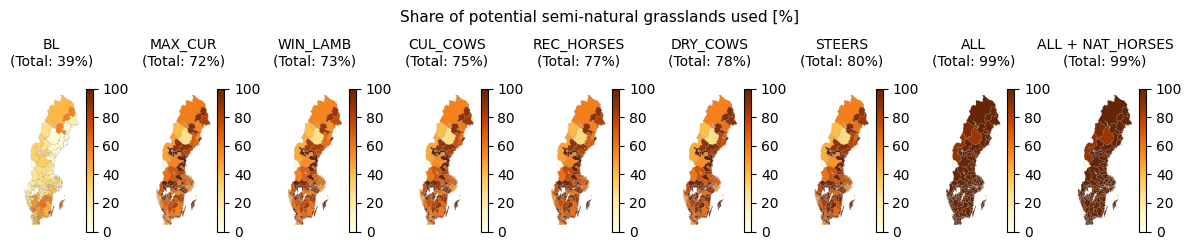

In [24]:
sng_use = session.get_attr('c','area',{'crop':'land_use', 'region':None}).loc[scn_final,'semi-natural grasslands']
sng_pot = session.get_attr('r','max_land_use',['land_use','region']).loc[('MAX_CUR','100'),'semi-natural grasslands']
tot_share = (sng_use.sum(axis=1) / sng_pot.sum()).droplevel('year')*100

plot_data = (
    sng_use.div(sng_pot, axis=1)
    .droplevel('year')
) * 100

fig, axs = plt.subplots(1,len(sort), figsize=(12,2.5))
for n, scn in enumerate(sort):
    ax = axs[n]
    cm.plot.map_from_series(
        plot_data.loc[scn],
        ax = ax,
        vmin=0,
        vmax=100,
        **map_style
    )
    ax.set_title(f'{scn}\n(Total: {tot_share.loc[scn]:.0f}%)', size=10)
    ax.axis('off')
fig.suptitle('Share of potential semi-natural grasslands used [%]', size=11)
plt.tight_layout()
plt.show()

#### Share of max cropland

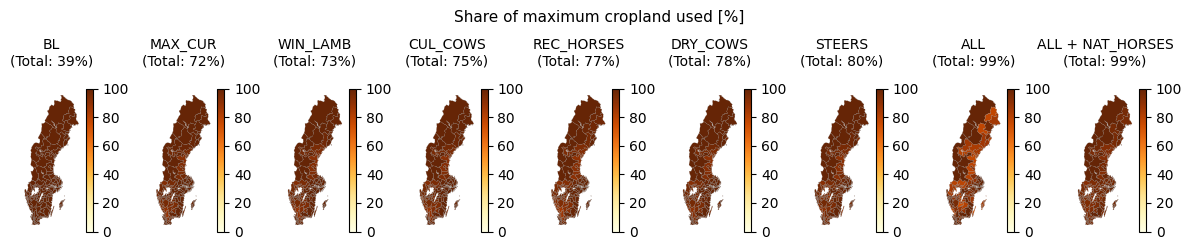

In [25]:
cropland_use = session.get_attr('c','area',{'crop':'land_use', 'region':None}).loc[scn_final,'cropland']
cropland_max = session.get_attr('r','max_land_use',['land_use','region']).loc[('MAX_CUR','100'),'cropland']
tot_share = (sng_use.sum(axis=1) / sng_pot.sum()).droplevel('year')*100

plot_data = (
    cropland_use.div(cropland_max, axis=1)
    .droplevel('year')
) * 100

fig, axs = plt.subplots(1,len(sort), figsize=(12,2.5))
for n, scn in enumerate(sort):
    ax = axs[n]
    cm.plot.map_from_series(
        plot_data.loc[scn],
        ax = ax,
        vmin=0,
        vmax=100,
        **map_style
    )
    ax.set_title(f'{scn}\n(Total: {tot_share.loc[scn]:.0f}%)', size=10)
    ax.axis('off')
fig.suptitle('Share of maximum cropland used [%]', size=11)
plt.tight_layout()
plt.show()

### Maps. Changes in animal herds

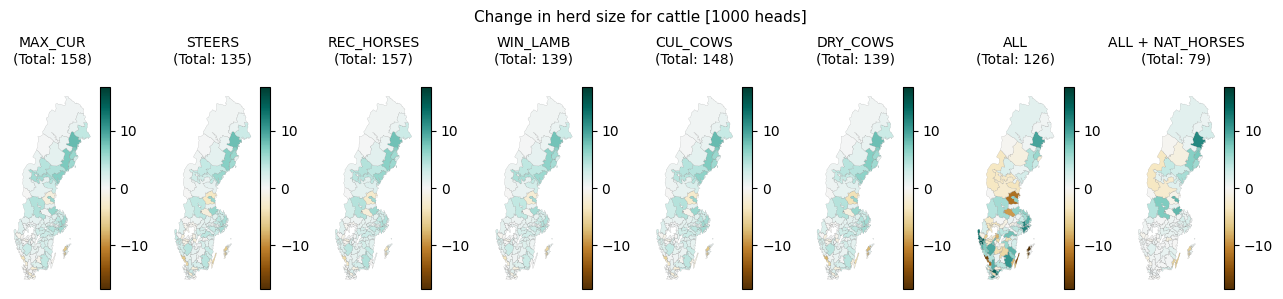

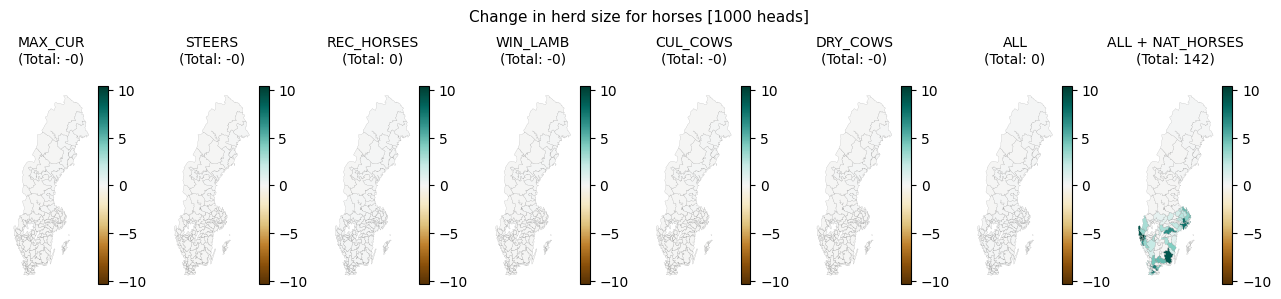

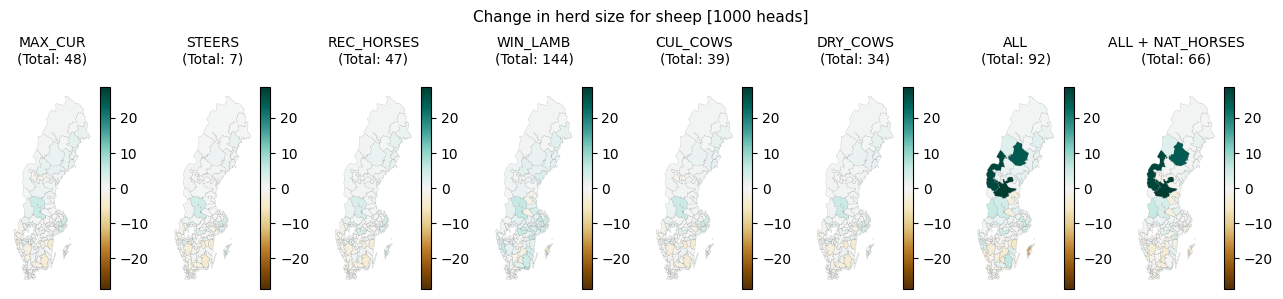

In [26]:
plot_data = (
    session.get_attr('a','heads',['region','species'])
    .loc[scn_final]
    .droplevel('year')
    .transform(lambda x: x.sub(x.loc[('BL')],axis=1))
    .drop('BL')
    .stack('region')
)/1000
# plot_data.columns = pd.Index([c[0] if c[0] != 'cattle' else ', '.join(c) for c in plot_data.columns], name='animal_system')
# plot_data = plot_data.T.groupby('animal_system').sum().T

plot_data = plot_data.drop(['pigs','poultry'], axis=1)

for ani in plot_data.columns:
    d = plot_data.loc[:,ani]

    lim = max(-min(d.values), max(d.values))
    
    fig, axs = plt.subplots(1,len(d.index.unique('scn')), figsize=(13,3))
    for n, scn in enumerate(d.index.unique('scn')):
        ax = axs[n]
        cm.plot.map_from_series(
            d.loc[scn],
            ax = ax,
            vmin = -lim,
            vmax = lim,
            **map_style_div
        )
        ax.set_title(f'{scn}\n(Total: {d.loc[scn].sum():.0f})', size=10)
        ax.axis('off')
    fig.suptitle(f'Change in herd size for {ani} [1000 heads]', size=11)
    plt.tight_layout()
    plt.show()

## Run scenarios (multi proc.)

In [14]:
# Import
from concurrent.futures import ProcessPoolExecutor, as_completed
from multi_proc import do_run

In [15]:
# Create list of scenarios to run
runs = [(s,y) for s,y in session.iterate('no output')]
runs

[('NAT_HORSES', '70'), ('NAT_HORSES', '100'), ('NAT_HORSES', '110')]

In [16]:
%%time
# Do the multi-processing
with ProcessPoolExecutor(max_workers=8) as executor:
    
    futures = {executor.submit(do_run, session, scn_year) : scn_year for scn_year in runs}

    for future in as_completed(futures):
    
        scn, year = futures[future]
           
        try:
            t = future.result()
        except Exception as ee:
            print(f'(!!!) {scn}, {year} failed with the exception: {ee}')
        else:
            m = int(t/60)
            s = int(round(t - m*60))
            print(f'{scn}, {year} finished successfully in {m}min {s}s')
            
session.cache.clear()

NAT_HORSES, 100 finished successfully in 3min 24s
NAT_HORSES, 70 finished successfully in 3min 38s
NAT_HORSES, 110 finished successfully in 3min 40s
CPU times: total: 0 ns
Wall time: 4min 8s


## Run scenarios here

In [20]:
import sys
import os
import time
from contextlib import redirect_stdout, redirect_stderr
import numpy as np
import scipy
import cvxpy
import matplotlib.pyplot as plt
sys.path.insert(0, 'C:/Users/jnka0003/Git repos/CIBUSmod')
import CIBUSmod as cm
from CIBUSmod.utils.helpers import check_constraints

In [21]:
scn = 'ALL'
year = '110'

In [22]:
# Regions south of around 60 degrees north
south_of_60 = pd.Series({
    '111':True,
    '112':True,
    '311':True,
    '312':True,
    '321':True,
    '322':True,
    '411':True,
    '421':True,
    '422':True,
    '431':True,
    '511':True,
    '512':True,
    '513':True,
    '514':True,
    '515':True,
    '521':True,
    '611':True,
    '612':True,
    '621':True,
    '622':True,
    '711':True,
    '731':True,
    '811':True,
    '812':True,
    '813':True,
    '814':True,
    '821':True,
    '831':True,
    '911':True,
    '912':True,
    '913':True,
    '1011':True,
    '1111':True,
    '1112':True,
    '1121':True,
    '1122':True,
    '1123':True,
    '1124':True,
    '1131':True,
    '1211':True,
    '1212':True,
    '1213':True,
    '1214':True,
    '1215':True,
    '1216':True,
    '1221':True,
    '1222':True,
    '1311':True,
    '1321':True,
    '1322':True,
    '1331':True,
    '1411':True,
    '1412':True,
    '1421':True,
    '1511':True,
    '1512':True,
    '1521':True,
    '1522':True,
    '1611':True,
    '1612':True,
    '1613':True,
    '1614':True,
    '1615':True,
    '1616':True,
    '1617':True,
    '1621':True,
    '1622':True,
    '1623':True,
    '1711':True,
    '1712':True,
    '1713':True,
    '1721':True,
    '1722':True,
    '1723':True,
    '1724':False,
    '1811':True,
    '1812':True,
    '1813':True,
    '1821':True,
    '1911':True,
    '1912':True,
    '1921':True,
    '1922':True,
    '2011':False,
    '2012':False,
    '2019':False,
    '2111':False,
    '2121':False,
    '2122':False,
    '2211':False,
    '2212':False,
    '2221':False,
    '2311':False,
    '2312':False,
    '2319':False,
    '2331':False,
    '2411':False,
    '2412':False,
    '2413':False,
    '2414':False,
    '2415':False,
    '2419':False,
    '2511':False,
    '2512':False,
    '2519':False,
    '2521':False
}).rename_axis('region')

def _max_sng_obj_alt1(crops, geodist):

    import cvxpy

    print('Making max SNG objective (alt. 1) ...')

    yields = crops.data_attr.get('harvest')

    geodist.define_cvx_problem()

    # Get x variable
    x = geodist.problem.variables()[0]

    # Create objective
    rel = cm.ParameterRetriever.get_rel('crop','land_use')
    P = np.concatenate([
        np.zeros(len(geodist.x_idx_short['ani'])),
        np.array([yields.loc[(cr,ps,re)] if rel[cr] == 'semi-natural grasslands' else 0 for cr,ps,re in geodist.x_idx_short['crp']])
    ])
    obj = cvxpy.Maximize(
        cvxpy.sum(cvxpy.multiply(P, x))
    )
    
    # Create problem
    geodist.problem = cvxpy.Problem(
        objective = obj,
        constraints = geodist.problem.constraints
    )

    return None

def _max_sng_obj_alt2(geodist):

    print('Making max SNG objective (alt. 1) ...')

    for w in ['ani','crp']:
        for k in geodist.x0_idx[w].unique(0):
            if k not in ['Semi-natural pastures', 'Semi-natural pastures, wooded', 'Semi-natural pastures, thin soils', 'Semi-natural meadows']:
                cm.helpers.drop_from_objective(geodist, which=w, key=k)

    return None

def _make_ani_cons(geodist, name, M, b, rel):
    
    from CIBUSmod.optimisation.geo_dist import IndexedMatrix

    if isinstance(M, pd.DataFrame):
        row_idx = M.index
    else:
        row_idx = pd.Index([name])

    # Create A matrix
    M = scipy.sparse.csc_matrix(M)
    Z = scipy.sparse.csc_matrix((M.shape[0],len(geodist.x_idx_short['crp']))) # Zero matrix
    A = scipy.sparse.hstack([M,Z], format='csc')
    A = IndexedMatrix(
        matrix=A,
        row_idx=row_idx,
        col_idx={k:v.copy() for k,v in geodist.x_idx_short.items()}
    )

    # Append constraint
    geodist.constraints.update({f'{name}: A @ x {rel} b' : {
        'left' : lambda x,A: A.M @ x,
        'right' : lambda A: b,
        'rel' : rel,
        'pars' : {'A':A}
    }})

    return None

def _get_herds_par(herds, attr):
    
    res = pd.concat([
        pd.concat({h.species: 
            pd.concat({h.breed:
                pd.concat({h.prod_system:
                    pd.concat({h.sub_system:
                        h.data_attr.get(attr)
                    }, names=['sub_system'])
                }, names=['prod_system'])
            }, names=['breed'])
        }, names=['species'])
    for h in herds])

    return res

def _make_CH4_cons(herds, geodist, feed_mgmt, baseline_CH4, factor):

    print('Making CH4 constraint ...')
    
    feed_mgmt.calculate2()
    
    # Get CH4 emissions per defining animal
    CH4 = _get_herds_par(herds, 'enteric_methane').sum(axis=1).reindex(geodist.x_idx_short['ani'])
    
    # Assert that indexes match
    assert (CH4.index == geodist.x_idx_short['ani']).all()
    
    _make_ani_cons(geodist, name='CH4', M=CH4, b=baseline_CH4 * factor, rel='<=')

    return None

def _make_milkmeat_cons(herds, geodist, baseline_milkmeat):

    print('Making milk/meat constraint ...')

    # Get milk and meat prod. per defining animal
    meat = _get_herds_par(herds, 'production').xs('meat', level='animal_prod', axis=1).sum(axis=1).xs('cattle', drop_level=False).reindex(geodist.x_idx_short['ani'], fill_value=0)
    milk = _get_herds_par(herds, 'production').xs('milk', level='animal_prod', axis=1).sum(axis=1).xs('cattle', drop_level=False).reindex(geodist.x_idx_short['ani'], fill_value=0)
    milkmeat = (milk - meat*baseline_milkmeat)
    _make_ani_cons(geodist, name='milk/meat', M=milkmeat, b=0, rel='==')

    return None

def _make_orgcon_cons(geodist, baseline_org_per_con):

    print('Making org/con constraint ...')
    
    d = [[(-1/baseline_org_per_con.loc[sp,br] if ps=='organic' else 1) if (sp==sp2) and (br==br2) else 0 for sp,br,ps,_,_ in geodist.x_idx_short['ani']] for sp2,br2 in baseline_org_per_con.index]
    M = pd.DataFrame(
        d,
        index = baseline_org_per_con.index,
        columns = geodist.x_idx_short['ani']
    )
    _make_ani_cons(geodist, name='org/con', M=M, b=0, rel='==')
    
    return None

def _make_beeflamb_cons(herds, geodist, baseline_beeflamb):

    print('Making beef/lamb constraint ...')

    # Get beef and lamb prod. per defining animal
    beef = _get_herds_par(herds, 'production').xs('meat', level='animal_prod', axis=1).sum(axis=1).xs('cattle', drop_level=False).reindex(geodist.x_idx_short['ani'], fill_value=0)
    lamb = _get_herds_par(herds, 'production').xs('meat', level='animal_prod', axis=1).sum(axis=1).xs('sheep', drop_level=False).reindex(geodist.x_idx_short['ani'], fill_value=0)
    beeflamb = (beef - lamb*baseline_beeflamb)
    _make_ani_cons(geodist, name='beef/lamb', M=beeflamb, b=0, rel='==')

    return None

def _make_sng_cons(geodist, sng_areas, tol=0.001):

    print('Making SNG constraint ...')

    geodist.make_C9(C9_crp = sng_areas * (1-tol), C9_rel = '>=')
    geodist.make_C7()

C:\Users\jnka0003\Git repos\CIBUSmod\data
CREATING MODULES
STARTING MODEL RUN


C:\Users/jnka0003/Git repos/CIBUSmod\CIBUSmod\utils\retriever.py:152: UserWarning: 
-----------------------------------------------------------------------------
Some filter values included in data were not available in relation_tables.xlsx.
Missing for 'crop': 'Lentils'
Missing for 'animal': 'calves'
Missing for 'feed': 'maize gluten meal', 'rapeseed cake', 'minerals'
Missing for 'by_prod': 'fish meal', 'cream', 'soybean meal', 'palm kernel expeller', 'luzern meal', 'soybean protein concentrate'
------------------------------------------------------------------------------
  warnings.warn(f"""
C:\Users/jnka0003/Git repos/CIBUSmod\CIBUSmod\utils\retriever.py:164: UserWarning: 
--------------------------------------------------------------------------------------------
Data includes crop(s) without an x0 area specified through 'x0_crops' in the Regions module.
Missing: 'Lentils'
--------------------------------------------------------------------------------------------
  warnings.warn(

[21:06:23][Regions] Getting initial crop areas and animal numbers (x0) ... 0.1s
[21:06:23][Regions] Getting climate and soil attributes ... 0.1s
[21:06:23][Regions] Calculating maximum land use ... 0.0s
[21:06:23][Regions] Done! Elapsed time: 0 sec
[21:06:23][DemandAndConversions] Calculating food demand ... 0.1s
[21:06:23][DemandAndConversions] Resolving recipies for compound foods ... 0.0s
[21:06:23][DemandAndConversions] Calculating waste ... 0.0s
[21:06:23][DemandAndConversions] Calculating product demand and generated by-products... 0.3s
[21:06:23][DemandAndConversions] Done! Elapsed time: 0 sec
[21:06:23][CropProduction] Calculating harvest ... 0.1s
[21:06:23][CropProduction] Calculating production ... 0.7s
[21:06:24][CropProduction] Calculating crop residues ... 0.1s
[21:06:24][CropProduction] Calculating seed demand ... 0.2s
[21:06:24][CropProduction] Done! Elapsed time: 1 sec
[21:06:24][AnimalHerd (cattle, beef, conventional, ley based)] Calculating herd structure ... 0.5s
[21

C:\Users/jnka0003/Git repos/CIBUSmod\CIBUSmod\utils\helpers.py:213: PerformanceWarning: indexing past lexsort depth may impact performance.
  drop_locs, drop_idx = idx.get_loc_level(key, level=level, drop_level=False)


Making CH4 constraint ...
Making milk/meat constraint ...
Making beef/lamb constraint ...
Making org/con constraint ...
Making max SNG objective (alt. 1) ...
[21:07:15][GeoDistributor.solve] Finding solution with 'GUROBI' ... Set parameter Username
Academic license - for non-commercial use only - expires 2025-08-28
Optimal solution found! Status: 'optimal', Iterations: 2313.0, Solver: 'GUROBI' 0.6s
[21:07:16][GeoDistributor.solve] Retrieving solution ... 0.0s
[21:07:16][GeoDistributor.solve] Done! Elapsed time: 1 sec
SNG area: 1.14 Mha
Optimisation round #2
[21:07:16][GeoDistributor.make] Getting x0 and making indexes ... 0.0s
[21:07:16][GeoDistributor.make] Creating demand vector ... 0.3s
[21:07:16][GeoDistributor.make] Calculating scaling factors ... 0.3s
[21:07:17][GeoDistributor.make] Making objective O1 ... 0.2s
[21:07:17][GeoDistributor.make] Making constraint C1 ... 9.1s
[21:07:26][GeoDistributor.make] Making constraint C2 ... 0.7s
[21:07:27][GeoDistributor.make] Making constrai

C:\Users/jnka0003/Git repos/CIBUSmod\CIBUSmod\utils\helpers.py:213: PerformanceWarning: indexing past lexsort depth may impact performance.
  drop_locs, drop_idx = idx.get_loc_level(key, level=level, drop_level=False)


Making CH4 constraint ...
Making milk/meat constraint ...
Making beef/lamb constraint ...
Making org/con constraint ...
Making SNG constraint ...
BarConvTol = 1.0e-08
[21:07:40][GeoDistributor.solve] Defining problem ... 0.0s
[21:07:40][GeoDistributor.solve] Finding solution with 'GUROBI' ... Optimal solution found! Status: 'optimal', Iterations: 55.0, Solver: 'GUROBI' 1.3s
[21:07:41][GeoDistributor.solve] Retrieving solution ... 0.0s
[21:07:41][GeoDistributor.solve] Applying solution ... 1.4s
[21:07:43][GeoDistributor.solve] Done! Elapsed time: 3 sec
SNG area: 1.14 Mha
[21:07:43][FeedMgmt] Adjusting feed rations (not implemented) ... 0.0s
[21:07:43][FeedMgmt] Calculating feed ration characteristics ... 8.2s
[21:07:51][FeedMgmt] Calculating enteric methane emissions ... 1.1s
[21:07:52][FeedMgmt] Done! Elapsed time: 9 sec
[21:07:52][ByProductMgmt] Inducing imports of by-products to cover demand ... 0.0s
[21:07:52][ByProductMgmt] Allocating residual by-products to waste management and ex

C:\Users/jnka0003/Git repos/CIBUSmod\CIBUSmod\utils\session_db.py:1533: UserWarning: NaNs in CropProduction.energy_use_supply_chain_emissions.
  warnings.warn(f'NaNs in {module.par.name}.{attr}.')
C:\Users/jnka0003/Git repos/CIBUSmod\CIBUSmod\utils\session_db.py:1535: UserWarning: Negative values of down to -327825239.5743066 */year in AnimalHerd.feed_req_min.
  warnings.warn(f'Negative values of down to {data.min().min()} {module.data_attr[attr]["unit"]} in {module_name}.{attr}.')
C:\Users/jnka0003/Git repos/CIBUSmod\CIBUSmod\utils\session_db.py:1533: UserWarning: NaNs in WasteAndCircularity.losses_VS.
  warnings.warn(f'NaNs in {module.par.name}.{attr}.')
C:\Users/jnka0003/Git repos/CIBUSmod\CIBUSmod\utils\session_db.py:1533: UserWarning: NaNs in WasteAndCircularity.losses_N.
  warnings.warn(f'NaNs in {module.par.name}.{attr}.')
C:\Users/jnka0003/Git repos/CIBUSmod\CIBUSmod\utils\session_db.py:1533: UserWarning: NaNs in WasteAndCircularity.losses_P.
  warnings.warn(f'NaNs in {module.p

Outputs stored!
ALL, 110 finished successfully in 3min 18s


[(conventional, pigs, meat)       0.000000e+00
 (conventional, poultry, eggs)   -8.940697e-08
 (conventional, poultry, meat)    0.000000e+00
 (organic, pigs, meat)            2.793968e-09
 (organic, poultry, eggs)        -1.490116e-08
                                      ...     
 (organic, maize)                 6.039045e-10
 (conventional, triticale)       -1.478475e-07
 (organic, triticale)            -1.014268e-08
 (conventional, maize fodder)     7.078052e-08
 (organic, maize fodder)          0.000000e+00
 Name: C1: A1 @ x == b1, Length: 88, dtype: float64,
 crop_prod  prod_system   region
 barley     conventional  1011      1.072628e+07
                          111       9.150635e+06
                          1111      1.548564e+07
                          1112      8.195036e+06
                          112       9.505403e+06
                                        ...     
 oats       organic       821       1.383579e+05
                          831       5.245965e-09
     

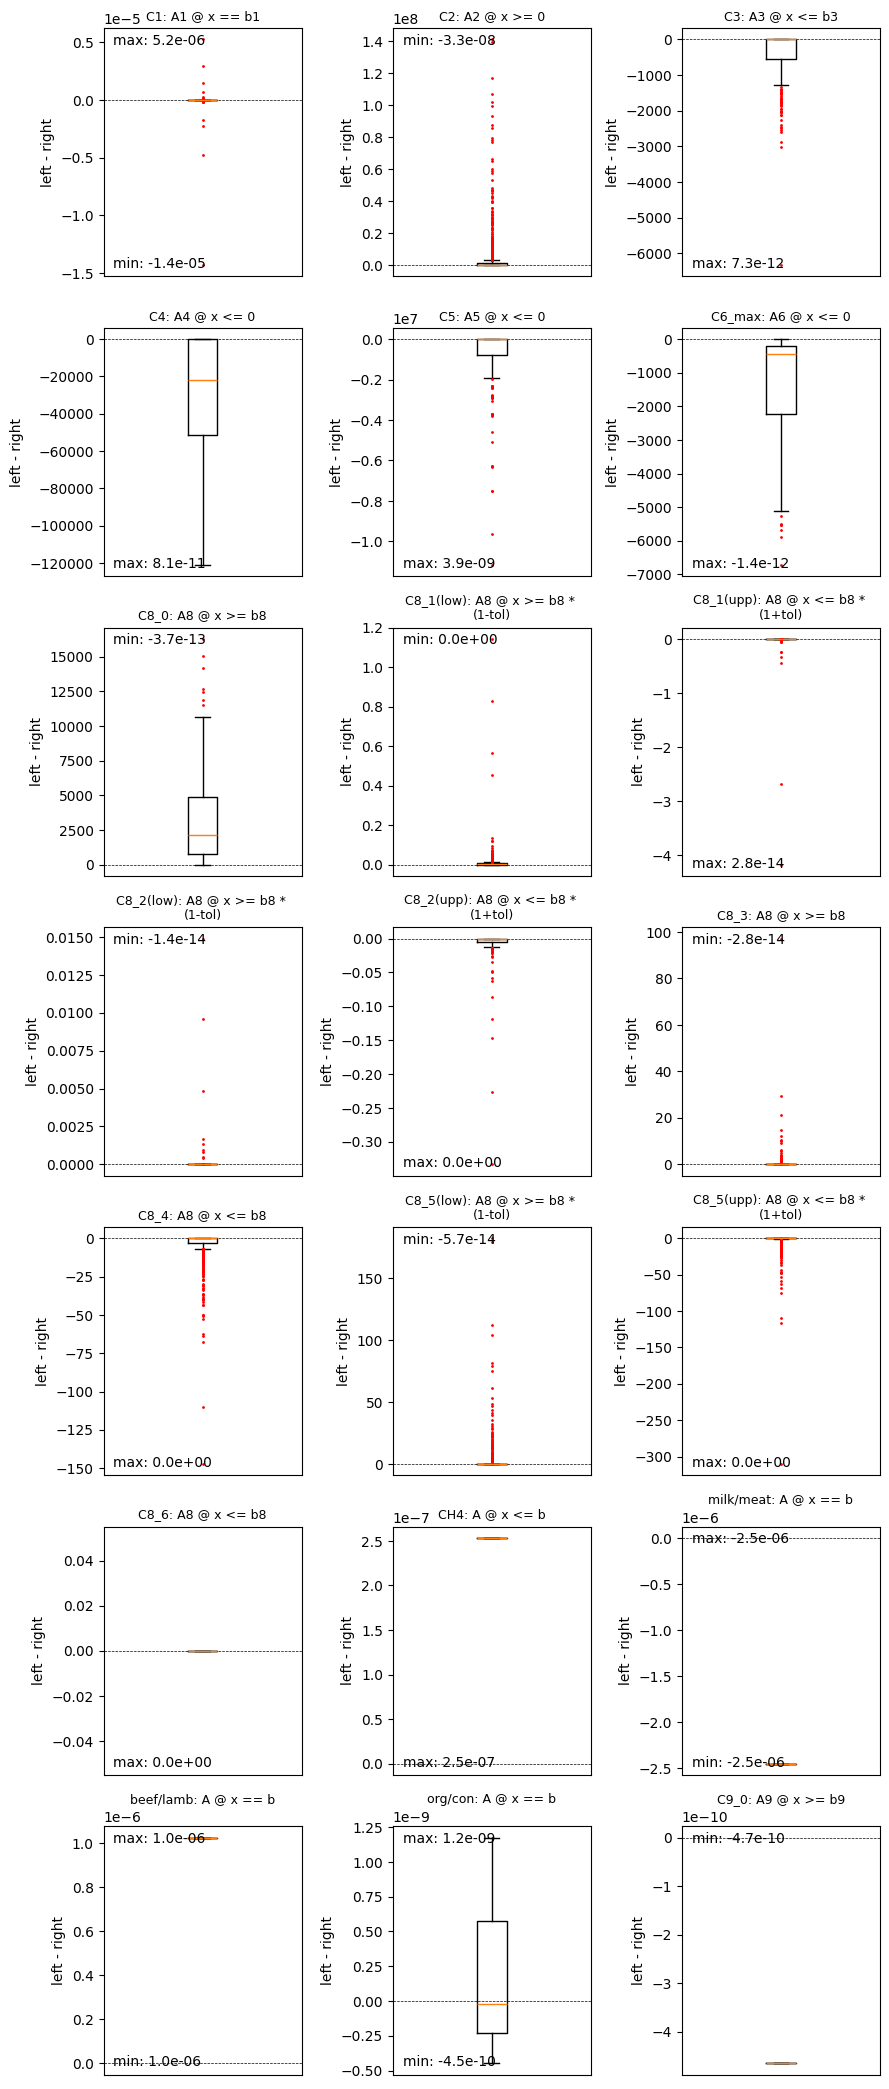

In [23]:
print(session.data_path)

tic = time.time()

# Increase timeout to avoid failing to write if multiple processes try to write at the same time
session.db_timeout = 60

###############################
###   INSTANTIATE MODULES   ###
###############################

print('CREATING MODULES')

# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions'),
    settings = {'max_land_use_from_scenario_x0' : True}
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    index = regions.data_attr.get('x0_crops').index
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# If Nature conservation horses scenario add new horse breed
if session[scn]['scenario_workbooks'] is not None and 'NAT_HORSES' in session[scn]['scenario_workbooks']:
    nat_horses = True
    h = cm.HorseHerd(
        par = cm.ParameterRetriever('HorseHerd'),
        index = regions.data_attr.get('x0_animals').index.get_level_values('region').unique(),
        breed = 'conservation horses',
        prod_system = 'conventional',
        sub_system = 'none'
    )
    s = pd.Series(
        [h],
        index = pd.MultiIndex.from_tuples(
            [(h.species, h.breed, h.prod_system, h.sub_system)],
            names = ['species','breed','prod_system','sub_system']
        )
    )
    herds = pd.concat([herds, s])
else:
    nat_horses = False

# Instantiate WasteAndCircularity
waste = cm.WasteAndCircularity(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('WasteAndCircularity')
)

# Instantiate WasteAndCircularity
waste = cm.WasteAndCircularity(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('WasteAndCircularity')
)

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate by-product management
byprod_mgmt = cm.ByProductMgmt(
    demand = demand,
    herds = herds,
    par = cm.ParameterRetriever('ByProductMgmt')
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('ManureMgmt'),
    settings = {
        'NPK_excretion_from_balance' : True
    }
)

# Instantiate crop residue managment
crop_residue_mgmt = cm.CropResidueMgmt(
    demand = demand,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('CropResidueMgmt')
)

# Instantiate plant nutrient management
plant_nutrient_mgmt = cm.PlantNutrientMgmt(
    demand = demand,
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('PlantNutrientMgmt')
)

# Instatiate machinery and energy management
machinery_and_energy_mgmt  = cm.MachineryAndEnergyMgmt(
    regions = regions,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('MachineryAndEnergyMgmt')
)

# Instatiate inputs management
inputs = cm.InputsMgmt(
    demand = demand,
    crops = crops,
    waste = waste,
    herds = herds,
    par = cm.ParameterRetriever('InputsMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

############################
###   RUN CALCULATIONS   ###
############################

print('STARTING MODEL RUN')

# Update all parameter values
cm.ParameterRetriever.update_all_parameter_values(
    **session[scn],
    year = year
)

# Get region attributes
regions.calculate(verbose=True)

# Calculate food demand
demand.calculate(verbose=True)

# Calculate crops
crops.calculate(verbose=True)

# Calculate herds
for h in herds:
    h.calculate(verbose=True)

# Calculate feed
feed_mgmt.calculate(verbose=True)

# Get data from baseline
if scn != 'BL':
    while True:
        try:
            # Get baseline crop areas, animal numbers and land use
            baseline_ani = session.get_attr('geo','x_animals', scn='BL').iloc[0]
            baseline_crp = session.get_attr('geo','x_crops', scn='BL').iloc[0]
            baseline_lu = session.get_attr('c','area',{'region':None, 'crop':'land_use'}, scn='BL').iloc[0].unstack()
            # Get baseline CH4 emissions
            baseline_CH4 = session.get_attr(
                'A', 'enteric_methane',
                'none',
                scn='BL'
            ).iloc[0]
            # Get baseline milk/meat
            prod = session.get_attr('A', 'prod', ['species', 'animal_prod'], scn='BL').iloc[0]
            baseline_milkmeat = prod[('cattle','milk')] / prod[('cattle','meat')]
            # Get baseline beef/lamb
            prod = session.get_attr('A', 'prod', ['species','animal_prod'], scn='BL').iloc[0]
            baseline_beeflamb = prod[('cattle','meat')] / prod[('sheep','meat')]
            # Get baseline org/con
            heads = session.get_attr('G','x_ani',['species','breed','prod_system'], scn='BL').iloc[0].loc[['cattle','sheep']]
            baseline_org_per_con = (heads.xs('organic', level='prod_system') / heads.xs('conventional', level='prod_system'))
        except:
            time.sleep(10)
        else:
            break

# Distribute animals and crops
# Make optimisation problem
if scn == 'BL':
    geodist.make(
        use_cons=[1,2,3,4,5,6,7],
        scale_power=0.4,
        verbose=True
    )
    # Solve optimisation problem
    geodist.solve(verbose=True)
else:
    # Drop demand for cattle, sheep and horses
    demand.data_attr.update(
        'animal_prod_demand',
        demand.data_attr.get('animal_prod_demand')
        .loc[(slice(None),['pigs','poultry'],slice(None))]
    )

    # Set maximum cropland and greenhouse area to baseline levels
    regions.data_attr.get('max_land_use').update(baseline_lu.loc[:,['cropland','greenhouse']])

    # Baseline Semi-natural grassland areas
    C8_SNG_P = baseline_crp.copy()\
    .loc[['Semi-natural pastures']]
    C8_SNG_PWT = baseline_crp.copy()\
    .loc[['Semi-natural pastures, wooded','Semi-natural pastures, thin soils']]
    C8_SNG_M = baseline_crp.copy()\
    .loc[['Semi-natural meadows']]
    C8_FAL = baseline_crp.copy()\
    .loc[['Fallow', 'Ley not harvested']]
    C8_FOD = baseline_crp.copy()\
    .loc[['Cereals for fodder', 'Other crops for fodder']]
    C8_ani = baseline_ani.copy()

    for opt_nr in [1,2]:
        print(f'Optimisation round #{opt_nr}')
        geodist.make(
            use_cons=[1,2,3,4,5,6,7,8],
            scale_power=0 if opt_nr==1 else 0.4,
            C8_crp = [ C8_SNG_P,   C8_SNG_PWT,   C8_SNG_M,   C8_FAL,  C8_FOD,   None                                     ],
            C8_ani = [ None,       None,         None,       None,    None,     C8_ani.loc[['horses','pigs','poultry']]  ],
            C8_rel = [ '>=',       '==',         '==',       '>=',    '<=',     '=='                                     ],
            verbose=True
        )

        if nat_horses:
            # No nature conservation hoses below ~60 degrees north
            idx = pd.IndexSlice
            nat_horses_lim = pd.Series(
                0.0,
                index = geodist.x_idx['ani'].to_frame()
                .loc[idx[
                    ['horses'],
                    ['conservation horses'],
                    :,
                    :,
                    south_of_60[~south_of_60].index
                ]].index
            )
            geodist.make_C8(
                C8_ani = nat_horses_lim,
                C8_rel = '<='
            )
            geodist.make_C7()
            # Drop conservation horses from objective
            cm.helpers.drop_from_objective(geodist, which='ani', key=('horses','conservation horses'))
            
        
        # Add constraint on CH4 emissions and milk/meat
        CH4_factor = float(year)/100
        _make_CH4_cons(herds, geodist, feed_mgmt, baseline_CH4, CH4_factor)
        _make_milkmeat_cons(herds, geodist, baseline_milkmeat)
        _make_beeflamb_cons(herds, geodist, baseline_beeflamb)
        _make_orgcon_cons(geodist, baseline_org_per_con)

        if opt_nr == 1:
            # First we solve while dropping everything from the
            # obejctive except for semi-natural grasslands
            _max_sng_obj_alt1(crops, geodist)
            geodist.solve(apply_solution=False, verbose=True)
            
            # Get semi-natural grassland areas from first solution to constrain
            # semi-natural grassland area per region for second optimization round
            sng_areas = geodist.x['crp'].loc[['Semi-natural pastures', 'Semi-natural pastures, thin soils', 'Semi-natural pastures, wooded']]
            # C8_SNG_P = geodist.x['crp'].loc[['Semi-natural pastures']] * (1-0.001)
            print(f'SNG area: {sng_areas.sum()/1_000_000:.2f} Mha')
        elif opt_nr == 2:           
            # Solve optimisation problem again, this time minimising deviation from current
            # crop areas and animal numbers
            _make_sng_cons(geodist, sng_areas, tol=0.001)
            for tol in [1e-8, 1e-7, 5e-7, 1e-6, 5e-6, 1e-5]:
                try:
                    print(f'BarConvTol = {tol:.1e}')
                    geodist.solve(solver_settings={'solver':'GUROBI', 'BarConvTol':tol}, verbose=True)
                except:
                    print('')
                    continue
                else:
                    break
            sng_areas = geodist.x['crp'].loc[['Semi-natural pastures', 'Semi-natural pastures, thin soils', 'Semi-natural pastures, wooded']]
            print(f'SNG area: {sng_areas.sum()/1_000_000:.2f} Mha')

# Redistribute feeds (not yet implemented) and calculate enteric CH4 emissions
feed_mgmt.calculate2(verbose=True)

# Balance by-product demand and suply
byprod_mgmt.calculate(verbose=True)

# Calculate manure
manure_mgmt.calculate(verbose=True)

# Calculate harvest of crop residues
crop_residue_mgmt.calculate(verbose=True)

# Calculate treatment of wastes and other feedstocks
waste.calculate(verbose=True)

# Calculate plant nutrient management
plant_nutrient_mgmt.calculate(verbose=True)

# Calculate energy requirements
machinery_and_energy_mgmt.calculate(verbose=True)

# Calculate inputs supply chain emissions
inputs.calculate(verbose=True)

# Store results (try again if first atempt fails)
try:
    session.store(
        scn, year,
        demand, regions, crops, herds, waste, geodist
    )
except:
    session.store(
        scn, year,
        demand, regions, crops, herds, waste, geodist
    )

t = time.time() - tic
m = int(t/60)
s = int(round(t - m*60))
print(f'{scn}, {year} finished successfully in {m}min {s}s')

check_constraints(geodist)

In [18]:
crops.data_attr.get('harvest')

crop           prod_system   region
Apples         conventional  1011      13240.640200
                             111        4723.912118
                             1111      19828.018920
                             1112      19808.858300
                             112        4587.113078
                                           ...     
Wheat, winter  organic       821        3526.455659
                             831        3643.726588
                             911        3559.286073
                             912        4234.993276
                             913        3765.950117
Length: 13568, dtype: float64